In [1]:
print("ram ram")

ram ram


In [2]:
# Uncomment if you need to install packages in your environment:
# !pip install litellm langchain-litellm langchain-core langgraph pandas psycopg2-binary sqlalchemy

import os
import uuid
import litellm
import pandas as pd
from typing import Annotated, Literal, Optional, Sequence
from typing_extensions import TypedDict
from sqlalchemy import create_engine, text

from langchain_litellm import ChatLiteLLM
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# Suppress LiteLLM verbose debugging logs
litellm.set_verbose = False

# Ensure API keys are loaded
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GROQ_API_KEY   = os.getenv("GROQ_API_KEY")

print("✅ Libraries and environment initialized.")

c:\Users\renuk\OneDrive\Desktop\denso code\super_agent_backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries and environment initialized.


In [3]:
# ── Primary LLM: Gemini (via LiteLLM Gateway) ──
orchestrator_llm_primary = ChatLiteLLM(
    model="gemini/gemini-3.5-flash-lite",
    api_key=GEMINI_API_KEY,
)

# ── Fallback LLM: Groq LLaMA 3 (via LiteLLM Gateway) ──
orchestrator_llm_fallback = ChatLiteLLM(
    model="groq/llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY,
)

_ACTIVE_PROVIDER = {"orchestrator": "gemini"}

def invoke_with_fallback(primary_llm, fallback_llm, messages: list, role: str, tools=None):
    """
    Acts as an LLM Gateway router: Tries the primary model, 
    automatically fails over to the fallback model if an error occurs.
    """
    global _ACTIVE_PROVIDER
    llm_primary  = primary_llm.bind_tools(tools)  if tools else primary_llm
    llm_fallback = fallback_llm.bind_tools(tools) if tools else fallback_llm

    try:
        result = llm_primary.invoke(messages)
        if _ACTIVE_PROVIDER[role] != "gemini":
            print(f"\n   [GATEWAY] {role.title()} recovered to primary (Gemini).")
        _ACTIVE_PROVIDER[role] = "gemini"
        return result
        
    except Exception as e:
        err_str = str(e)
        print(f"\n   [GATEWAY WARNING] Primary failed for {role}: {err_str[:120]}")
        print(f"   [GATEWAY] Routing to Fallback (Groq) for {role}...")
        _ACTIVE_PROVIDER[role] = "groq"
        
        try:
            result = llm_fallback.invoke(messages)
            print(f"   [GATEWAY SUCCESS] Fallback responded successfully for {role}.")
            return result
            
        except Exception as e2:
            raise RuntimeError(
                f"GATEWAY CRITICAL: Both Primary and Fallback failed for {role}.\n"
                f"Primary error: {err_str[:200]}\n"
                f"Fallback error: {str(e2)[:200]}"
            ) from e2

print("✅ LiteLLM Gateway initialized — Primary: Gemini | Fallback: Groq")

✅ LiteLLM Gateway initialized — Primary: Gemini | Fallback: Groq


In [ ]:
DB_USER = "postgres"
DB_PASSWORD = "0987654321"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "construction_ai"

try:
    engine = create_engine(
        f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )   
    # Quick connectivity test
    with engine.connect() as test_conn:
        test_conn.execute(text("SELECT 1"))
    print(f"✅ Connected to PostgreSQL Database: {DB_NAME}")
except Exception as e:
    engine = None
    print(f"⚠️ Database connection failed. Running in mock/offline mode. Error: {e}")

✅ Connected to PostgreSQL Database: construction_ai


In [5]:
import pandas as pd
from typing import Optional
from sqlalchemy import text
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

# ── Safe Query Execution Helper ──────────────────────────────────────────
BLOCKED_SQL_KEYWORDS = [
    "DROP", "DELETE", "UPDATE", "INSERT", "ALTER",
    "TRUNCATE", "EXEC", "EXECUTE", "CREATE", "MERGE"
]

def _execute_query(query: str, params: dict = None) -> str:
    """Executes a SQL SELECT query safely with parameters and returns formatted JSON."""
    if 'engine' not in globals() or engine is None:
        return "Error: Database engine is not initialized or connected."
    
    upper_query = query.upper()
    for keyword in BLOCKED_SQL_KEYWORDS:
        if keyword in upper_query.split():
            return f"Error: '{keyword}' operations are strictly forbidden on read-only database."
            
    try:
        with engine.connect() as conn:
            df = pd.read_sql_query(text(query), conn, params=params or {})
        if df.empty:
            return "No matching records found."
        return df.head(100).to_json(orient="records", date_format="iso", indent=2)
    except Exception as e:
        return f"Database Error: {str(e)}"


# =========================================================================
# 1. PPE & INCIDENT COMPLIANCE TOOLS (10 Tools)
# =========================================================================

@tool
def get_today_ppe_violations() -> str:
    """Fetches all PPE and safety violations recorded today."""
    query = """
        SELECT id, camera_id, camera_name, zone_id, track_id, class_name, confidence, 
               is_active, escalation_status, started_at
        FROM public.incidents
        WHERE DATE(started_at) = CURRENT_DATE
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_active_unremediated_violations(limit: int = 50) -> str:
    """Fetches all safety violations that are currently unresolved (is_active = TRUE and resolved_at IS NULL)."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, root_cause, 
               escalation_status, started_at, duration_seconds
        FROM public.incidents
        WHERE is_active = TRUE AND resolved_at IS NULL
        ORDER BY started_at ASC LIMIT :limit
    """
    return _execute_query(query, {"limit": limit})

@tool
def get_hard_hat_violations_status(is_active: bool = True) -> str:
    """Retrieves all hard hat (helmet) violations filtered by active status."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, confidence, 
               started_at, resolved_at, is_active
        FROM public.incidents
        WHERE LOWER(class_name) LIKE '%helmet%' OR LOWER(class_name) LIKE '%hard%hat%'
          AND is_active = :is_active
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query, {"is_active": is_active})

@tool
def get_incident_by_id(incident_id: int) -> str:
    """Fetches comprehensive details for a specific safety violation using its primary Incident ID."""
    query = "SELECT * FROM public.incidents WHERE id = :inc_id"
    return _execute_query(query, {"inc_id": incident_id})

@tool
def get_oldest_unresolved_incident() -> str:
    """Retrieves the oldest open/unresolved safety violation currently in the database."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, root_cause, 
               escalation_status, started_at, EXTRACT(EPOCH FROM (NOW() - started_at))/3600 AS open_hours
        FROM public.incidents
        WHERE is_active = TRUE AND resolved_at IS NULL
        ORDER BY started_at ASC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_remediation_duration_analytics(class_name: Optional[str] = None) -> str:
    """Calculates average, min, and max remediation duration (in seconds/minutes) for closed safety violations."""
    query = """
        SELECT class_name, 
               COUNT(*) AS total_resolved,
               AVG(duration_seconds) AS avg_duration_sec,
               AVG(duration_seconds)/60.0 AS avg_duration_minutes,
               MAX(duration_seconds)/60.0 AS max_duration_minutes
        FROM public.incidents
        WHERE resolved_at IS NOT NULL AND duration_seconds IS NOT NULL
    """
    params = {}
    if class_name:
        query += " AND LOWER(class_name) LIKE LOWER(:class_name)"
        params["class_name"] = f"%{class_name}%"
    query += " GROUP BY class_name ORDER BY avg_duration_sec DESC LIMIT 20"
    return _execute_query(query, params)

@tool
def get_longest_duration_remediated_violation() -> str:
    """Fetches the safety violation that took the longest time to be remediated and closed."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, root_cause, 
               started_at, resolved_at, duration_seconds, (duration_seconds / 3600.0) AS duration_hours
        FROM public.incidents
        WHERE resolved_at IS NOT NULL
        ORDER BY duration_seconds DESC NULLS LAST LIMIT 1
    """
    return _execute_query(query)

@tool
def get_same_day_remediated_incidents(limit: int = 50) -> str:
    """Finds all safety incidents that were detected and resolved on the exact same calendar day."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, 
               started_at, resolved_at, duration_seconds
        FROM public.incidents
        WHERE DATE(started_at) = DATE(resolved_at) AND resolved_at IS NOT NULL
        ORDER BY started_at DESC LIMIT :limit
    """
    return _execute_query(query, {"limit": limit})

@tool
def get_recurring_violations_list(limit: int = 50) -> str:
    """Lists incidents flagged by computer vision as recurring safety violations."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, escalation_status, 
               started_at, duration_seconds
        FROM public.incidents
        WHERE is_recurring = TRUE
        ORDER BY started_at DESC LIMIT :limit
    """
    return _execute_query(query, {"limit": limit})

@tool
def get_incidents_by_date(target_date: str = "2026-08-10") -> str:
    """Retrieves all safety incidents recorded across all cameras/sites on a specific date (YYYY-MM-DD)."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, confidence, 
               is_active, started_at, resolved_at
        FROM public.incidents
        WHERE DATE(started_at) = DATE(:t_date)
        ORDER BY started_at ASC LIMIT 100
    """
    return _execute_query(query, {"t_date": target_date})


# =========================================================================
# 2. HSE RULE DEFINITIONS & CAMERA RULES (8 Tools)
# =========================================================================

@tool
def get_all_hse_rules(is_active: Optional[bool] = None) -> str:
    """Retrieves all defined HSE safety rules with condition trees and alert configs."""
    query = "SELECT id, name, description, group_id, is_template, is_active, created_at FROM public.hse_rule_definitions WHERE 1=1"
    params = {}
    if is_active is not None:
        query += " AND is_active = :active"
        params["active"] = is_active
    query += " ORDER BY id ASC LIMIT 100"
    return _execute_query(query, params)

@tool
def get_hse_rule_by_id(rule_id: int) -> str:
    """Fetches full description, configuration, and condition logic for a specific HSE rule ID."""
    query = "SELECT * FROM public.hse_rule_definitions WHERE id = :r_id"
    return _execute_query(query, {"r_id": rule_id})

@tool
def get_top_broken_hse_rules(days: int = 30, limit: int = 5) -> str:
    """Calculates the top most frequently triggered HSE rules within the last N days."""
    query = """
        SELECT r.id AS rule_id, r.name AS rule_name, r.description, COUNT(e.id) AS violation_count
        FROM public.hse_rule_events e
        JOIN public.hse_rule_definitions r ON e.rule_id = r.id
        WHERE e.triggered_at >= NOW() - (INTERVAL '1 day' * :days)
        GROUP BY r.id, r.name, r.description
        ORDER BY violation_count DESC LIMIT :limit
    """
    return _execute_query(query, {"days": days, "limit": limit})

@tool
def get_rules_violated_over_threshold(min_count: int = 10, days: int = 30) -> str:
    """Lists safety rules that have been violated more than a specific count threshold within a timeframe."""
    query = """
        SELECT r.id AS rule_id, r.name AS rule_name, COUNT(e.id) AS violation_count
        FROM public.hse_rule_events e
        JOIN public.hse_rule_definitions r ON e.rule_id = r.id
        WHERE e.triggered_at >= NOW() - (INTERVAL '1 day' * :days)
        GROUP BY r.id, r.name
        HAVING COUNT(e.id) > :min_count
        ORDER BY violation_count DESC
    """
    return _execute_query(query, {"days": days, "min_count": min_count})

@tool
def get_unviolated_rules_this_year(year: int = 2026) -> str:
    """Finds all active safety rules that have logged zero violations during the given year."""
    query = """
        SELECT r.id, r.name, r.description, r.is_active
        FROM public.hse_rule_definitions r
        WHERE r.is_active = TRUE
          AND r.id NOT IN (
              SELECT DISTINCT rule_id 
              FROM public.hse_rule_events 
              WHERE EXTRACT(YEAR FROM triggered_at) = :yr AND rule_id IS NOT NULL
          )
        ORDER BY r.id ASC
    """
    return _execute_query(query, {"yr": year})

@tool
def get_fall_protection_rules() -> str:
    """Retrieves all HSE rules related to Fall Protection, heights, or worker collapse."""
    query = """
        SELECT id, name, description, condition_tree, alert_config, is_active
        FROM public.hse_rule_definitions
        WHERE LOWER(name) LIKE '%fall%' OR LOWER(description) LIKE '%fall%'
           OR LOWER(name) LIKE '%height%' OR LOWER(name) LIKE '%collapse%'
    """
    return _execute_query(query)

@tool
def get_rules_modified_this_year(year: int = 2026) -> str:
    """Lists safety rules added or modified in the database during the specified year."""
    query = """
        SELECT id, name, description, created_at, updated_at, is_active
        FROM public.hse_rule_definitions
        WHERE EXTRACT(YEAR FROM created_at) = :yr OR EXTRACT(YEAR FROM updated_at) = :yr
        ORDER BY updated_at DESC
    """
    return _execute_query(query, {"yr": year})

@tool
def get_rules_violated_across_all_cameras() -> str:
    """Lists safety rules that were triggered at least once on every single active camera."""
    query = """
        SELECT r.id, r.name, COUNT(DISTINCT e.camera_id) AS distinct_cameras_count
        FROM public.hse_rule_definitions r
        JOIN public.hse_rule_events e ON r.id = e.rule_id
        GROUP BY r.id, r.name
        HAVING COUNT(DISTINCT e.camera_id) = (SELECT COUNT(*) FROM public.cameras WHERE status = 'active')
    """
    return _execute_query(query)


# =========================================================================
# 3. SITE, PLANT, LOCATION & CAMERA METRICS (8 Tools)
# =========================================================================

@tool
def get_violations_by_site_and_plant() -> str:
    """Aggregates total safety violations and alerts broken down by Plant, Location, and Department."""
    query = """
        SELECT p.name AS plant_name, l.name AS location_name, d.name AS department_name, 
               COUNT(i.id) AS total_incidents,
               COUNT(CASE WHEN i.is_active = TRUE THEN 1 END) AS active_incidents
        FROM public.cameras c
        LEFT JOIN public.plants p ON c.plant_id = p.id
        LEFT JOIN public.locations l ON c.location_id = l.id
        LEFT JOIN public.departments d ON c.department_id = d.id
        LEFT JOIN public.incidents i ON c.id = i.camera_id
        GROUP BY p.name, l.name, d.name
        ORDER BY total_incidents DESC
    """
    return _execute_query(query)

@tool
def get_top_violating_site_last_week() -> str:
    """Finds the specific site/plant that registered the highest number of safety violations in the past 7 days."""
    query = """
        SELECT p.id AS plant_id, p.name AS plant_name, l.name AS location_name, COUNT(i.id) AS violations_last_week
        FROM public.incidents i
        JOIN public.cameras c ON i.camera_id = c.id
        JOIN public.plants p ON c.plant_id = p.id
        LEFT JOIN public.locations l ON p.location_id = l.id
        WHERE i.started_at >= NOW() - INTERVAL '7 days'
        GROUP BY p.id, p.name, l.name
        ORDER BY violations_last_week DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_site_remediation_track_record() -> str:
    """Ranks all sites/plants based on their violation resolution efficiency and open violation count."""
    query = """
        SELECT p.name AS plant_name,
               COUNT(i.id) AS total_incidents,
               COUNT(CASE WHEN i.resolved_at IS NOT NULL THEN 1 END) AS remediated_count,
               COUNT(CASE WHEN i.is_active = TRUE THEN 1 END) AS unremediated_count,
               ROUND((COUNT(CASE WHEN i.resolved_at IS NOT NULL THEN 1 END)::NUMERIC / NULLIF(COUNT(i.id), 0)) * 100, 2) AS resolution_rate_pct
        FROM public.plants p
        JOIN public.cameras c ON p.id = c.plant_id
        LEFT JOIN public.incidents i ON c.id = i.camera_id
        GROUP BY p.name
        ORDER BY unremediated_count DESC, resolution_rate_pct ASC
    """
    return _execute_query(query)

@tool
def get_open_violations_for_site(site_id: int) -> str:
    """Lists all open safety violations for a specific site (plant_id or location_id)."""
    query = """
        SELECT i.id, i.camera_name, i.zone_id, i.track_id, i.class_name, i.confidence, i.started_at
        FROM public.incidents i
        JOIN public.cameras c ON i.camera_id = c.id
        WHERE (c.plant_id = :site_id OR c.location_id = :site_id) AND i.is_active = TRUE
        ORDER BY i.started_at DESC
    """
    return _execute_query(query, {"site_id": site_id})

@tool
def get_sites_with_zero_violations() -> str:
    """Finds active plants or locations that have zero safety violations logged."""
    query = """
        SELECT p.id, p.name AS plant_name, p.description, l.name AS location_name
        FROM public.plants p
        LEFT JOIN public.locations l ON p.location_id = l.id
        WHERE p.id NOT IN (
            SELECT DISTINCT c.plant_id 
            FROM public.cameras c 
            JOIN public.incidents i ON c.id = i.camera_id 
            WHERE c.plant_id IS NOT NULL
        )
    """
    return _execute_query(query)

@tool
def get_camera_operational_status_logs() -> str:
    """Retrieves the latest operational status logs (online, offline, error) for all cameras."""
    query = """
        SELECT c.id AS camera_id, c.name AS camera_name, c.ip, c.status AS configured_status,
               l.status AS latest_log_status, l.checked_at
        FROM public.cameras c
        LEFT JOIN (
            SELECT DISTINCT ON (camera_id) camera_id, status, checked_at
            FROM public.camera_status_logs
            ORDER BY camera_id, checked_at DESC
        ) l ON c.id = l.camera_id
        ORDER BY c.id ASC
    """
    return _execute_query(query)

@tool
def get_average_violations_per_camera_for_site(site_id: int) -> str:
    """Calculates the average number of violations detected per camera for a given plant/site ID."""
    query = """
        SELECT c.plant_id,
               COUNT(DISTINCT c.id) AS total_cameras,
               COUNT(i.id) AS total_violations,
               ROUND(COUNT(i.id)::NUMERIC / NULLIF(COUNT(DISTINCT c.id), 0), 2) AS avg_violations_per_camera
        FROM public.cameras c
        LEFT JOIN public.incidents i ON c.id = i.camera_id
        WHERE c.plant_id = :site_id
        GROUP BY c.plant_id
    """
    return _execute_query(query, {"site_id": site_id})

@tool
def get_rules_exclusive_to_site(site_id: int) -> str:
    """Identifies safety rules that have been violated exclusively at one specific site/plant ID."""
    query = """
        SELECT r.id AS rule_id, r.name AS rule_name
        FROM public.hse_rule_definitions r
        JOIN public.hse_rule_events e ON r.id = e.rule_id
        JOIN public.cameras c ON e.camera_id = c.id
        GROUP BY r.id, r.name
        HAVING COUNT(DISTINCT c.plant_id) = 1 AND MAX(c.plant_id) = :site_id
    """
    return _execute_query(query, {"site_id": site_id})


# =========================================================================
# 4. TEMPORAL & SHIFT ANALYTICS (6 Tools)
# =========================================================================

@tool
def get_hourly_violation_distribution() -> str:
    """Shows peak hours of the day (0-23) when safety and behavior violations occur most frequently."""
    query = """
        SELECT EXTRACT(HOUR FROM started_at) AS hour_of_day,
               COUNT(*) AS violation_count,
               COUNT(CASE WHEN LOWER(class_name) LIKE '%ppe%' OR LOWER(class_name) LIKE '%helmet%' THEN 1 END) AS ppe_count,
               COUNT(CASE WHEN LOWER(class_name) NOT LIKE '%ppe%' AND LOWER(class_name) NOT LIKE '%helmet%' THEN 1 END) AS behavior_count
        FROM public.incidents
        GROUP BY hour_of_day
        ORDER BY violation_count DESC
    """
    return _execute_query(query)

@tool
def get_night_shift_violations() -> str:
    """Lists safety violations that were flagged during night shift hours (e.g. 20:00 to 06:00)."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, started_at
        FROM public.incidents
        WHERE EXTRACT(HOUR FROM started_at) >= 20 OR EXTRACT(HOUR FROM started_at) < 6
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_weekend_shift_inspections() -> str:
    """Fetches operator shift assignments and patrol logs recorded during weekend shifts (Saturday/Sunday)."""
    query = """
        SELECT s.name AS shift_name, o.assignment_date, u.full_name AS operator_name, c.name AS camera_name
        FROM public.operator_shift_assignments o
        JOIN public.shifts s ON o.shift_id = s.id
        JOIN public.users u ON o.user_id = u.id
        LEFT JOIN public.cameras c ON o.camera_id = c.id
        WHERE EXTRACT(DOW FROM o.assignment_date) IN (0, 6)
        ORDER BY o.assignment_date DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_yesterday_morning_violations() -> str:
    """Retrieves all safety violations logged yesterday before 12:00 PM noon."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, confidence, started_at
        FROM public.incidents
        WHERE DATE(started_at) = CURRENT_DATE - INTERVAL '1 day'
          AND EXTRACT(HOUR FROM started_at) < 12
        ORDER BY started_at ASC
    """
    return _execute_query(query)

@tool
def get_weekly_violation_trends(weeks: int = 8) -> str:
    """Provides a weekly aggregated trend of safety violations across all cameras."""
    query = """
        SELECT DATE_TRUNC('week', started_at) AS week_start,
               COUNT(*) AS total_violations,
               COUNT(CASE WHEN is_recurring = TRUE THEN 1 END) AS recurring_count
        FROM public.incidents
        WHERE started_at >= NOW() - (INTERVAL '1 week' * :wks)
        GROUP BY week_start
        ORDER BY week_start ASC
    """
    return _execute_query(query, {"wks": weeks})

@tool
def get_month_over_month_violation_comparison(year: int = 2026) -> str:
    """Generates month-over-month comparison of total safety violations for a given year."""
    query = """
        SELECT TO_CHAR(started_at, 'YYYY-MM') AS month_year,
               COUNT(*) AS total_violations,
               COUNT(CASE WHEN resolved_at IS NOT NULL THEN 1 END) AS resolved_violations
        FROM public.incidents
        WHERE EXTRACT(YEAR FROM started_at) = :yr
        GROUP BY month_year
        ORDER BY month_year ASC
    """
    return _execute_query(query, {"yr": year})


# =========================================================================
# 5. RESTRICTED ZONES & RISK SCORES (6 Tools)
# =========================================================================

@tool
def get_highest_risk_zones(limit: int = 10) -> str:
    """Ranks monitored zones by their calculated risk score, event count, and high severity incidents."""
    query = """
        SELECT zr.zone_id, z.name AS zone_name, z.zone_type, c.name AS camera_name,
               zr.risk_score, zr.risk_level, zr.event_count, zr.high_severity_count, zr.top_class
        FROM public.zone_risk_scores zr
        LEFT JOIN public.zones z ON zr.zone_id = z.id
        LEFT JOIN public.cameras c ON zr.camera_id = c.id
        ORDER BY zr.risk_score DESC LIMIT :limit
    """
    return _execute_query(query, {"limit": limit})

@tool
def get_unauthorized_hazard_zone_breaches(limit: int = 50) -> str:
    """Fetches all violations involving unauthorized entry into restricted/hazard zones."""
    query = """
        SELECT i.id, i.camera_name, z.name AS zone_name, z.zone_type, i.track_id, 
               i.class_name, i.started_at, i.duration_seconds
        FROM public.incidents i
        JOIN public.zones z ON i.zone_id = z.id
        WHERE LOWER(z.zone_type) LIKE '%hazard%' OR LOWER(z.zone_type) LIKE '%restricted%'
           OR LOWER(i.class_name) LIKE '%zone%' OR LOWER(i.class_name) LIKE '%entry%'
        ORDER BY i.started_at DESC LIMIT :limit
    """
    return _execute_query(query, {"limit": limit})

@tool
def get_zone_safety_profile(zone_id: int) -> str:
    """Returns active configurations, operating hours, coordinates, and risk scores for a specific Zone ID."""
    query = """
        SELECT z.*, zr.risk_score, zr.risk_level, zr.event_count, zr.top_class
        FROM public.zones z
        LEFT JOIN public.zone_risk_scores zr ON z.id = zr.zone_id
        WHERE z.id = :z_id
    """
    return _execute_query(query, {"z_id": zone_id})

@tool
def get_correlated_safety_events(min_risk: float = 0.5) -> str:
    """Retrieves multi-signal correlated safety events where multiple classes triggered a compound risk score."""
    query = """
        SELECT id, camera_id, zone_id, classes, risk_score, window_minutes, narrative, created_at
        FROM public.correlated_events
        WHERE risk_score >= :m_risk
        ORDER BY risk_score DESC, created_at DESC LIMIT 50
    """
    return _execute_query(query, {"m_risk": min_risk})

@tool
def get_active_anomaly_flags() -> str:
    """Lists anomaly flags where computer vision observed safety values deviating significantly from baseline."""
    query = """
        SELECT id, anomaly_type, severity, description, baseline_value, observed_value, deviation_factor, event_count, created_at
        FROM public.anomaly_flags
        WHERE is_acknowledged = FALSE
        ORDER BY deviation_factor DESC NULLS LAST LIMIT 50
    """
    return _execute_query(query)

@tool
def get_agent_recommendations_summary() -> str:
    """Retrieves unacknowledged safety and HSE recommendations generated by AI safety agents."""
    query = """
        SELECT id, agent_id, category, priority, title, description, created_at
        FROM public.agent_recommendations
        WHERE is_acknowledged = FALSE AND is_dismissed = FALSE
        ORDER BY created_at DESC LIMIT 50
    """
    return _execute_query(query)


# =========================================================================
# 6. EMPLOYEE, VISITOR & PATROL MOVEMENTS (7 Tools)
# =========================================================================

@tool
def get_repeat_offender_employees(min_violations: int = 2) -> str:
    """Identifies employees observed with multiple safety violations or restricted attendance punches."""
    query = """
        SELECT e.employee_id, e.employee_name, e.department, e.plant,
               COUNT(a.id) AS restricted_punches_count
        FROM public.employees e
        JOIN public.attendances a ON e.employee_id = a.employee_id
        WHERE a.is_restricted = TRUE
        GROUP BY e.employee_id, e.employee_name, e.department, e.plant
        HAVING COUNT(a.id) >= :min_v
        ORDER BY restricted_punches_count DESC
    """
    return _execute_query(query, {"min_v": min_violations})

@tool
def get_employee_safety_profile(employee_id: str) -> str:
    """Fetches full demographic, movement, and restricted area logs for a specific Employee ID."""
    query = """
        SELECT e.employee_id, e.employee_name, e.email, e.department, e.plant,
               a.timestamp AS punch_time, a.punch_type, a.is_restricted, a.duration_minutes
        FROM public.employees e
        LEFT JOIN public.attendances a ON e.employee_id = a.employee_id
        WHERE e.employee_id = :emp_id
        ORDER BY a.timestamp DESC LIMIT 50
    """
    return _execute_query(query, {"emp_id": employee_id})

@tool
def get_violations_by_department() -> str:
    """Ranks departments by total safety attendances and observations recorded."""
    query = """
        SELECT department_name, 
               COUNT(*) AS total_attendances,
               COUNT(CASE WHEN is_restricted = TRUE THEN 1 END) AS restricted_observations
        FROM public.attendances
        WHERE department_name IS NOT NULL
        GROUP BY department_name
        ORDER BY restricted_observations DESC
    """
    return _execute_query(query)

@tool
def get_security_patrol_status() -> str:
    """Retrieves checkpoints and completion status from security guard patrol logs."""
    query = """
        SELECT p.id, g.guard_id, g.name AS guard_name, p.checkpoint_name, 
               p.expected_time, p.actual_time, p.status
        FROM public.patrol_logs p
        JOIN public.security_guards g ON p.guard_id = g.id
        ORDER BY p.actual_time DESC NULLS LAST LIMIT 50
    """
    return _execute_query(query)

@tool
def get_active_visitor_logs() -> str:
    """Retrieves all active visitors currently on site and their host employee department."""
    query = """
        SELECT id, visitor_name, company, host_employee_id, department, plant, entry_time
        FROM public.visitors
        WHERE exit_time IS NULL
        ORDER BY entry_time DESC
    """
    return _execute_query(query)

@tool
def get_supervisor_overrides_history() -> str:
    """Fetches records of supervisor overrides for incident classifications, including reasons and operators involved."""
    query = """
        SELECT o.id, o.incident_id, u_op.full_name AS operator_name, u_sup.full_name AS supervisor_name,
               o.reason_code, o.video_clip_path, o.timestamp
        FROM public.supervisor_overrides o
        LEFT JOIN public.users u_op ON o.operator_id = u_op.id
        LEFT JOIN public.users u_sup ON o.supervisor_id = u_sup.id
        ORDER BY o.timestamp DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_user_activity_audit_logs(limit: int = 50) -> str:
    """Fetches user action audit logs (who modified rules, exported reports, or acknowledged alerts)."""
    query = """
        SELECT l.id, u.username, u.full_name, l.action, l.detail, l.ip_address, l.created_at
        FROM public.user_activity_logs l
        JOIN public.users u ON l.user_id = u.id
        ORDER BY l.created_at DESC LIMIT :limit
    """
    return _execute_query(query, {"limit": limit})


# =========================================================================
# 7. AI MODELS, NOTIFICATIONS & EVALUATION TEMPLATES (10 Tools)
# =========================================================================

@tool
def get_active_ai_models() -> str:
    """Lists deployed AI computer vision models, frameworks, TRT engine status, and batch sizes."""
    query = """
        SELECT id, name, version, framework, trt_ready, is_active, created_at
        FROM public.ai_models
        WHERE is_active = TRUE
    """
    return _execute_query(query)

@tool
def get_ai_model_classes_by_model(model_id: int) -> str:
    """Retrieves detectable class names (e.g. hard_hat, vest, person, collapse) for an AI model ID."""
    query = "SELECT id, model_id, class_name, class_index, color FROM public.ai_model_classes WHERE model_id = :m_id"
    return _execute_query(query, {"m_id": model_id})

@tool
def get_detection_assignments_matrix() -> str:
    """Fetches the active camera-to-model detection assignment matrix, FPS, and confidence thresholds."""
    query = """
        SELECT da.id, c.name AS camera_name, z.name AS zone_name, m.name AS model_name,
               da.label, da.confidence_threshold, da.inference_fps, da.alert_enabled, da.is_active
        FROM public.detection_assignments da
        JOIN public.cameras c ON da.camera_id = c.id
        LEFT JOIN public.zones z ON da.zone_id = z.id
        JOIN public.ai_models m ON da.model_id = m.id
        WHERE da.is_active = TRUE
    """
    return _execute_query(query)

@tool
def get_evaluator_templates() -> str:
    """Fetches preset evaluator configuration templates used for automated site assessments."""
    query = "SELECT id, name, description, base_type, preset_config, created_at FROM public.evaluator_templates"
    return _execute_query(query)

@tool
def get_notification_rules_and_channels() -> str:
    """Lists all configured notification rules, alert threshold counts, cooldowns, and channels (Email, Teams, Telegram, WhatsApp)."""
    query = "SELECT id, name, channels, threshold_count, cooldown_seconds, enabled, attach_snapshot, event_type FROM public.notification_rules"
    return _execute_query(query)

@tool
def get_failed_notification_logs(limit: int = 50) -> str:
    """Retrieves safety notification dispatch logs where the status is not 'sent' or encountered an error."""
    query = """
        SELECT id, rule_id, channel, recipient, status, response, created_at
        FROM public.notification_logs
        WHERE LOWER(status) != 'sent' AND LOWER(status) != 'success'
        ORDER BY created_at DESC LIMIT :limit
    """
    return _execute_query(query, {"limit": limit})

@tool
def get_scheduled_safety_reports() -> str:
    """Lists all automated scheduled HSE safety reports, send times, recipient channels, and frequencies."""
    query = """
        SELECT id, frequency, send_time, format, date_range, channels, email_recipients, is_active, last_sent_at
        FROM public.scheduled_reports
        WHERE is_active = TRUE
    """
    return _execute_query(query)

@tool
def get_system_security_settings() -> str:
    """Fetches global system settings including archive retention days, session timeouts, and 2FA policies."""
    query = "SELECT archive_days, auto_delete_low_severity, storage_location, session_timeout, enforce_2fa, api_token_expiry FROM public.system_settings LIMIT 1"
    return _execute_query(query)

@tool
def get_defect_detections_history(limit: int = 50) -> str:
    """Retrieves industrial visual defect detections logged from high-speed Basler cameras."""
    query = """
        SELECT id, basler_camera_id, model_name, class_name, confidence, bbox, created_at
        FROM public.defect_detections
        ORDER BY created_at DESC LIMIT :limit
    """
    return _execute_query(query, {"limit": limit})

@tool
def get_production_counting_summary() -> str:
    """Fetches latest counting snapshots and batch counts from conveyor tracking cameras."""
    query = """
        SELECT config_name, snapshot_date, total_count, count_in, count_out
        FROM public.counting_snapshots
        ORDER BY snapshot_date DESC LIMIT 50
    """
    return _execute_query(query)


# =========================================================================
# REGISTER ALL 55 TOOLS & CREATE TOOLNODE
# =========================================================================

hse_vision_tools = [
    # 1. PPE & Incidents
    get_today_ppe_violations,
    get_active_unremediated_violations,
    get_hard_hat_violations_status,
    get_incident_by_id,
    get_oldest_unresolved_incident,
    get_remediation_duration_analytics,
    get_longest_duration_remediated_violation,
    get_same_day_remediated_incidents,
    get_recurring_violations_list,
    get_incidents_by_date,
    
    # 2. HSE Rules
    get_all_hse_rules,
    get_hse_rule_by_id,
    get_top_broken_hse_rules,
    get_rules_violated_over_threshold,
    get_unviolated_rules_this_year,
    get_fall_protection_rules,
    get_rules_modified_this_year,
    get_rules_violated_across_all_cameras,
    
    # 3. Sites, Plants & Cameras
    get_violations_by_site_and_plant,
    get_top_violating_site_last_week,
    get_site_remediation_track_record,
    get_open_violations_for_site,
    get_sites_with_zero_violations,
    get_camera_operational_status_logs,
    get_average_violations_per_camera_for_site,
    get_rules_exclusive_to_site,
    
    # 4. Temporal & Shift Analytics
    get_hourly_violation_distribution,
    get_night_shift_violations,
    get_weekend_shift_inspections,
    get_yesterday_morning_violations,
    get_weekly_violation_trends,
    get_month_over_month_violation_comparison,
    
    # 5. Zones & Risks
    get_highest_risk_zones,
    get_unauthorized_hazard_zone_breaches,
    get_zone_safety_profile,
    get_correlated_safety_events,
    get_active_anomaly_flags,
    get_agent_recommendations_summary,
    
    # 6. Employees, Movements & Audits
    get_repeat_offender_employees,
    get_employee_safety_profile,
    get_violations_by_department,
    get_security_patrol_status,
    get_active_visitor_logs,
    get_supervisor_overrides_history,
    get_user_activity_audit_logs,
    
    # 7. AI Models & Settings
    get_active_ai_models,
    get_ai_model_classes_by_model,
    get_detection_assignments_matrix,
    get_evaluator_templates,
    get_notification_rules_and_channels,
    get_failed_notification_logs,
    get_scheduled_safety_reports,
    get_system_security_settings,
    get_defect_detections_history,
    get_production_counting_summary
]

tool_node = ToolNode(hse_vision_tools)
print(f"✅ Successfully registered {len(hse_vision_tools)} specialized HSE Vision tools into LangGraph ToolNode!")

✅ Successfully registered 55 specialized HSE Vision tools into LangGraph ToolNode!


In [6]:
# 1. Define Agent State
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 2. HSE Officer System Prompt
SYSTEM_PROMPT = """You are Deva, the PPE & Behavior Vision Agent (HSE Officer Assistant) created by Moksh Bhardwaj.
Address the user as 'sir'.

Your core responsibilities:
1. Detect & summarize PPE compliance (helmets, safety vests, eyewear) and unsafe acts (restricted-zone entries, fatigue, worker collapse).
2. Query the read-only HSE video analytics database using your available tools whenever the user asks for violation logs, camera status, active alerts, or zone risk analytics.
3. Present safety data in clean, scannable Markdown tables with key highlights.
4. If asked general operational questions about how this agent works, answer directly with candor.
"""

# 3. Define the Agent Node
def agent_node(state: State):
    """The main agent node executing with LiteLLM Gateway fallback."""
    messages = state["messages"]
    
    # Inject system prompt on initial turn
    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + messages
        
    response = invoke_with_fallback(
        primary_llm=orchestrator_llm_primary,
        fallback_llm=orchestrator_llm_fallback,
        messages=messages,
        role="orchestrator",
        tools=hse_vision_tools
    )
    return {"messages": [response]}

# 4. Define ReAct Conditional Routing
def route_tools(state: State) -> Literal["tools", "__end__"]:
    """Routes to 'tools' if the agent made tool calls; otherwise finishes the turn."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "__end__"

✅ PPE & Behavior Vision Agent Graph compiled successfully!


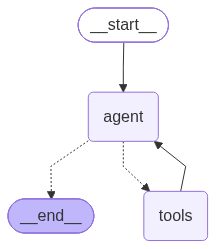

In [7]:
# Build the LangGraph StateGraph
workflow = StateGraph(State)

workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

# Flow: START -> agent
workflow.add_edge(START, "agent")

# Conditional: agent -> tools OR __end__
workflow.add_conditional_edges("agent", route_tools)

# Loop back: tools -> agent
workflow.add_edge("tools", "agent")

# Memory Saver for multi-turn conversational context
memory = MemorySaver()
deva_hse_agent = workflow.compile(checkpointer=memory)

print("✅ PPE & Behavior Vision Agent Graph compiled successfully!")
deva_hse_agent

In [8]:
def run_chat():
    """
    Runs an interactive conversational session in the notebook.
    Generates a unique session thread_id on each start.
    """
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}
    
    print("=" * 65)
    print("🦺 DEVA - PPE & BEHAVIOR VISION AGENT (HSE OFFICER)")
    print(f"Session Thread ID: {thread_id}")
    print("Type 'exit', 'quit', or 'break' to terminate the session.")
    print("=" * 65 + "\n")
    
    while True:
        user_input = input("You (Sir): ")
        
        if user_input.strip().lower() in ["exit", "quit", "break"]:
            print("\nExiting HSE session. Stay safe, sir!")
            break
            
        print("\nDeva is analyzing site intelligence...\n")
        
        events = deva_hse_agent.stream(
            {"messages": [("user", user_input)]},
            config=config,
            stream_mode="values"
        )
        
        for event in events:
            if "messages" in event:
                last_msg = event["messages"][-1]
                if last_msg.type == "ai" and last_msg.content:
                    print(f"Deva: {last_msg.content}\n")

# Start testing the agent
run_chat()

🦺 DEVA - PPE & BEHAVIOR VISION AGENT (HSE OFFICER)
Session Thread ID: 88bdd6dd-7a45-45ca-a09d-75487ed20b9b
Type 'exit', 'quit', or 'break' to terminate the session.


Deva is analyzing site intelligence...

Deva: Hello sir! I am Deva, your PPE & Behavior Vision Agent (HSE Officer Assistant) created by Moksh Bhardwaj. 

How can I assist you with safety compliance, incident logs, or zone analytics today, sir?


Deva is analyzing site intelligence...

Deva: Here is the breakdown of the top safety rule violations and computer vision events recorded across the system, sir:

### Top Safety Violations & Rule Triggers

| Rank | Safety Rule / Violation Class | Description / Context | Total / Trend |
| :---: | :--- | :--- | :--- |
| **1** | **No-Helmet** | Worker detected in monitored zone without a hard hat. | High frequency (Recurring on Camera 6) |
| **2** | **No-Vest** | Worker detected without a high-visibility safety vest. | Frequently flagged alongside headgear violations |
| **3** | **Pe